🌾 Crop Yield Prediction — Full Machine Learning Pipeline

Dataset: Crop Yield Prediction Dataset

Goal: Predict crop yield in tons per hectare (yield_tpha)

| #      | Section                   | Description                                                         |
| ------ | ------------------------- | ------------------------------------------------------------------- |
| **0**  | **Setup**                 | Libraries & Kaggle data import                                      |
| **1**  | **Data Loading**          | Load CSV, inspect dataset, initial exploration                      |
| **2**  | **Data Cleaning**         | Missing values, duplicates, invalid values, data types              |
| **3**  | **Preprocessing**         | Feature engineering, categorical encoding, numerical preprocessing  |
| **4**  | **EDA**                   | Target distribution, feature distributions, correlations, outliers  |
| **5**  | **Split & Scale**         | Train-test split, scaling numerical features                        |
| **6**  | **Model Training**        | Linear Regression, Ridge, Random Forest, Gradient Boosting, XGBoost |
| **7**  | **Evaluation**            | MAE, MSE, RMSE, R², actual vs predicted                             |
| **8**  | **Hyperparameter Tuning** | GridSearchCV / RandomizedSearchCV                                   |
| **9**  | **Feature Importance**    | Identify factors affecting crop yield                               |
| **10** | **Model Comparison**      | Compare all models and select the best one                          |
| **11** | **Save Model**            | Save final model, preprocessing pipeline with `joblib`              |
| **12** | **Prediction**            | Build function to predict yield for new crop conditions             |


0️⃣ Setup — Libraries

In [1]:
# ==============================
# 0. Setup — Libraries
# ==============================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save model
import joblib

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


Section 1: Data Loading & Initial Exploration

In [29]:
import os
import kagglehub

# تحميل أحدث إصدار من الداتاسيت عبر kagglehub
path = kagglehub.dataset_download('patelris/crop-yield-prediction-dataset')
print('Path to dataset files:', path)

# قراءة الملف المجمع النهائي yield_df.csv
csv_path = os.path.join(path, 'yield_df.csv')
df = pd.read_csv(csv_path)

# حذف عمود الـ index الزائد إن وجد
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print('Data source import complete.')
print('Shape:', df.shape)
df.head()

Using Colab cache for faster access to the 'crop-yield-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/crop-yield-prediction-dataset
Data source import complete.
Shape: (28242, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 2. Data Cleaning
In this section, we inspect and clean the dataset to prepare it for exploration and modeling:
- Check for missing values across all columns.
- Identify and remove duplicate rows to prevent bias.
- Verify data types to ensure numerical and categorical features are correctly formatted.
- Standardize column names (strip whitespace and format).

In [15]:
# 1. Check for missing values
print("--- Missing Values per Column ---")
print(df.isnull().sum())

# 2. Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\n--- Total Duplicate Rows: {duplicate_count} ---")

# 3. Check data types
print("\n--- Data Types ---")
print(df.dtypes)

--- Missing Values per Column ---
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

--- Total Duplicate Rows: 2310 ---

--- Data Types ---
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


### Deduplication & Data Type Normalization
- Drop duplicated records and reset the index.
- Strip leading and trailing whitespace from column names.
- Convert numerical columns stored as strings (if any) into appropriate numerical data types.

In [16]:
# Strip any unexpected whitespace from column names
df.columns = df.columns.str.strip()

# Drop duplicate rows
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Duplicates removed. New dataset shape: {df.shape}")
else:
    print("No duplicate rows found.")

# Verify numerical columns (e.g., rainfall, temperature, yield) are correctly cast
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features: {numeric_cols}")
print(f"Categorical features: {categorical_cols}")

# Display cleaned sample
df.head()


Duplicates removed. New dataset shape: (25932, 7)

Numerical features: ['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
Categorical features: ['Area', 'Item']


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 3. Exploratory Data Analysis (EDA)
In this section, we analyze the distribution and relationships of the features:
- Examine summary statistics for all numerical columns.
- Visualize the distribution of the target variable (`hg/ha_yield`).
- Analyze the correlation matrix between continuous features (rainfall, temperature, pesticides, and yield).
- Inspect crop yield variations across different crops and top countries.

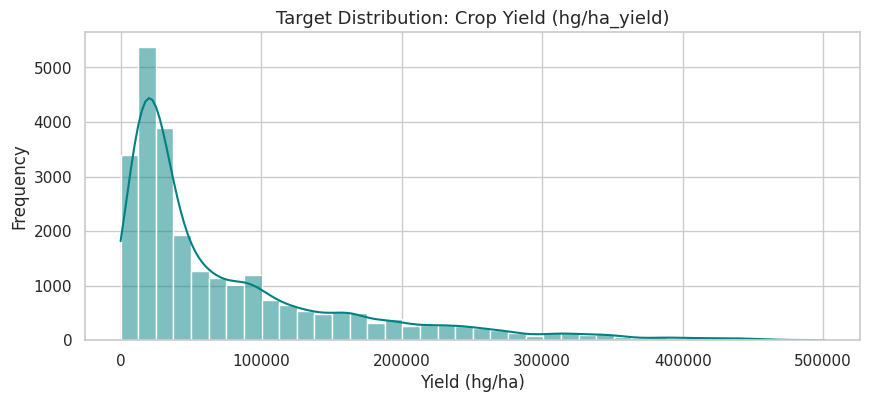

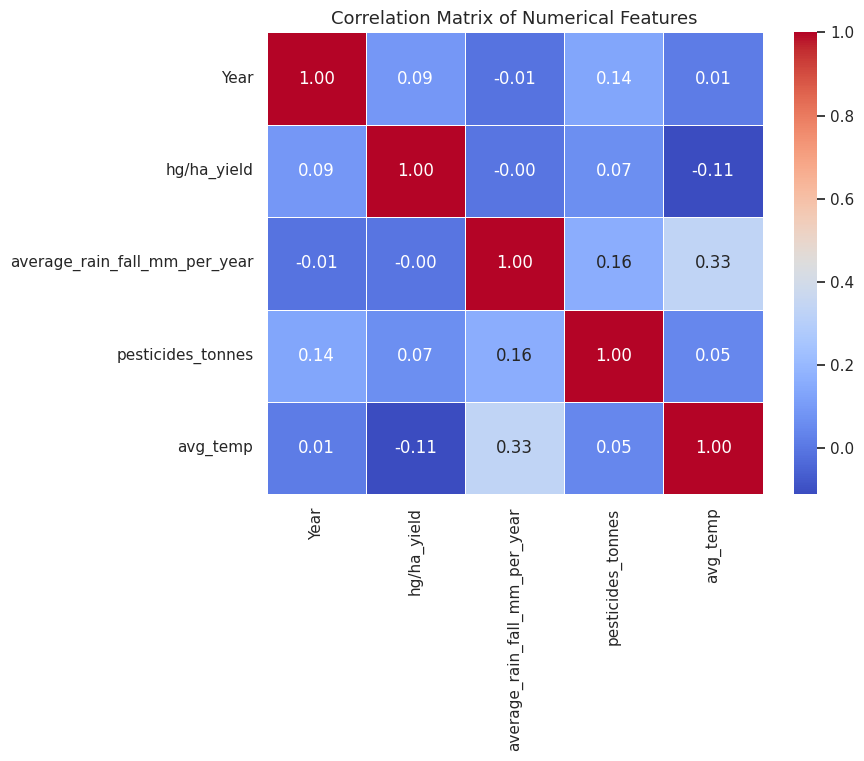

In [18]:
# Set style for visualizations
sns.set_theme(style="whitegrid")

# 1. Target variable distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['hg/ha_yield'], kde=True, color='teal', bins=40)
plt.title('Target Distribution: Crop Yield (hg/ha_yield)', fontsize=13)
plt.xlabel('Yield (hg/ha)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=13)
plt.show()

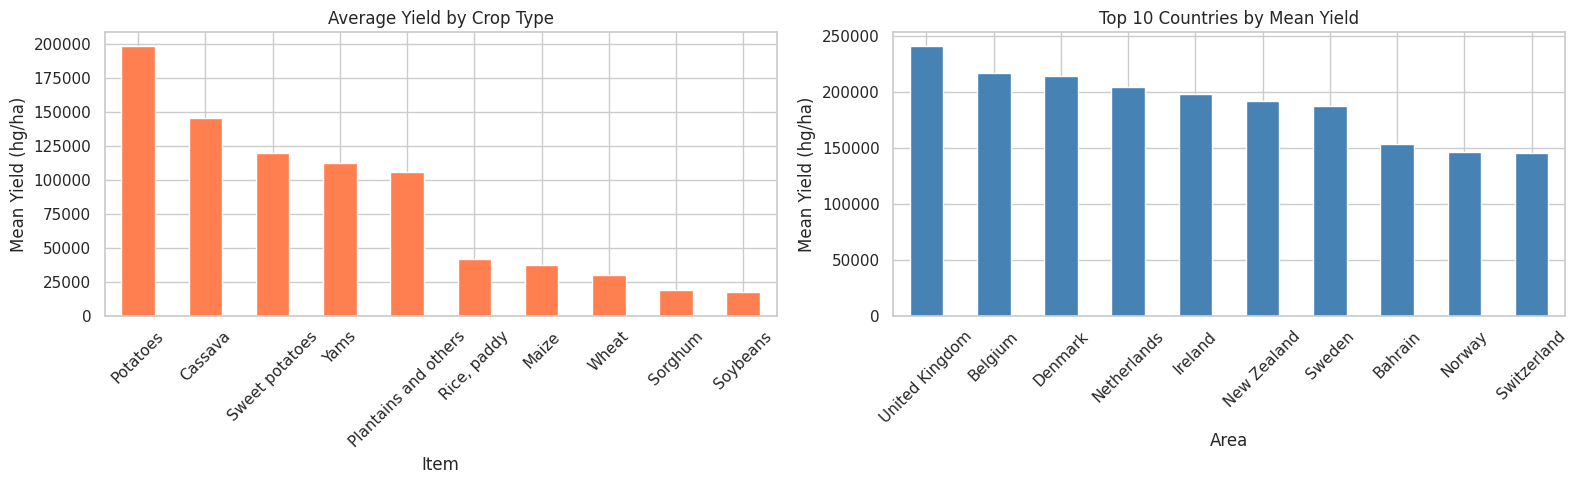

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average yield by item/crop
df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='coral'
)
axes[0].set_title('Average Yield by Crop Type', fontsize=12)
axes[0].set_ylabel('Mean Yield (hg/ha)')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 countries by total record count or average yield
top_countries = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Countries by Mean Yield', fontsize=12)
axes[1].set_ylabel('Mean Yield (hg/ha)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Advanced EDA: Trends, Outliers, and Feature Interactions
To gain deeper insights into the dataset dynamics, we inspect:
1. **Temporal Trend:** Annual average yield variation over time.
2. **Outlier Detection:** Boxplots for continuous numerical features.
3. **Feature Interactions:** Scatter plots of rainfall and pesticides against yield.

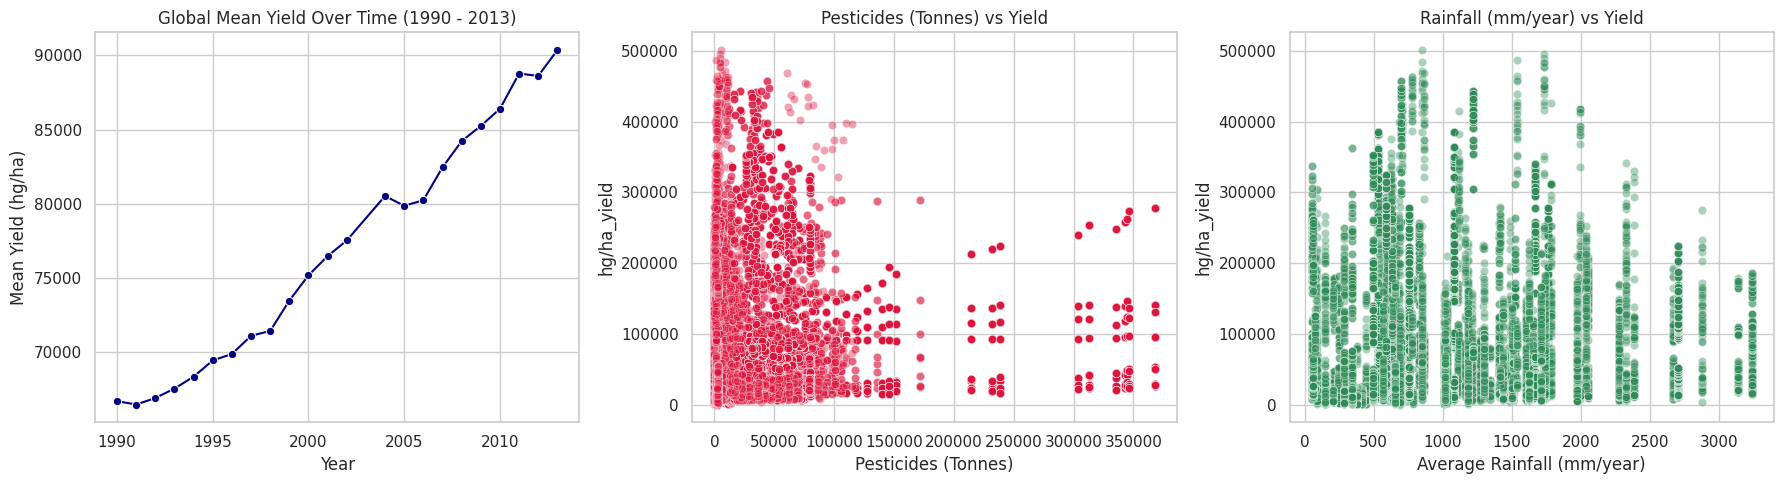

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Yield Trend over the Years
yearly_yield = df.groupby('Year')['hg/ha_yield'].mean().reset_index()
sns.lineplot(data=yearly_yield, x='Year', y='hg/ha_yield', marker='o', ax=axes[0], color='navy')
axes[0].set_title('Global Mean Yield Over Time (1990 - 2013)', fontsize=12)
axes[0].set_ylabel('Mean Yield (hg/ha)')

# 2. Pesticides vs Yield
sns.scatterplot(data=df, x='pesticides_tonnes', y='hg/ha_yield', alpha=0.4, ax=axes[1], color='crimson')
axes[1].set_title('Pesticides (Tonnes) vs Yield', fontsize=12)
axes[1].set_xlabel('Pesticides (Tonnes)')

# 3. Rainfall vs Yield
sns.scatterplot(data=df, x='average_rain_fall_mm_per_year', y='hg/ha_yield', alpha=0.4, ax=axes[2], color='seagreen')
axes[2].set_title('Rainfall (mm/year) vs Yield', fontsize=12)
axes[2].set_xlabel('Average Rainfall (mm/year)')

plt.tight_layout()
plt.show()

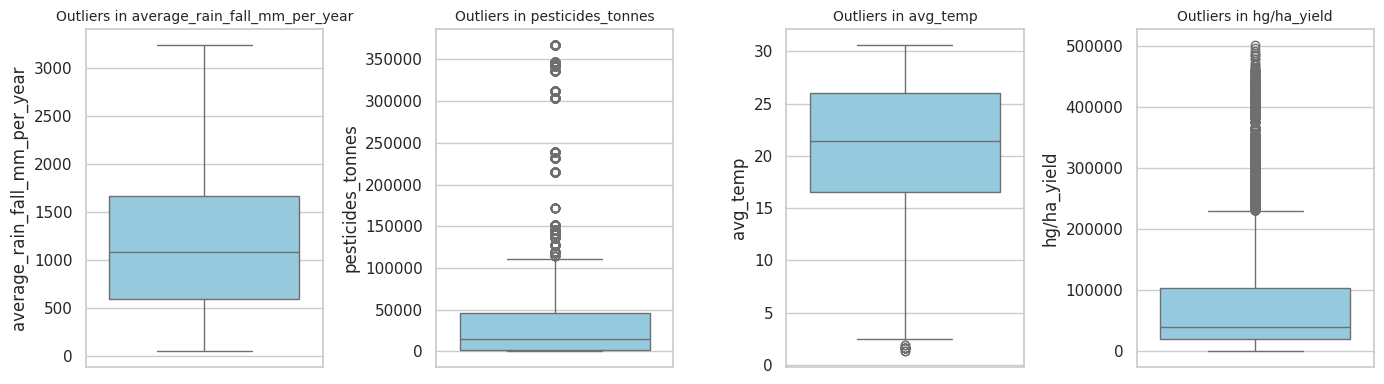

In [21]:
numerical_cols = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'hg/ha_yield']

plt.figure(figsize=(14, 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}', fontsize=10)
    plt.tight_layout()

plt.show()

## 4 & 5. Preprocessing and Train-Test Split
In this phase, we prepare the data pipeline for machine learning models:
1. **Feature-Target Separation:** Separate input features ($X$) from the target label ($y = \text{hg/ha\_yield}$).
2. **Train-Test Split:** Divide the dataset (80% training, 20% testing) using a fixed `random_state` for reproducibility.
3. **Data Preprocessing Pipeline:**
   - Apply `OneHotEncoder` to categorical features (`Area`, `Item`).
   - Apply `StandardScaler` to continuous numerical features (`Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`).

In [43]:
# 1. Features and Target
X = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']

# 2. Feature lists
categorical_features = ['Area', 'Item']
numerical_features = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

# 3. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# 5. Transform features
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train matrix shape: {X_train_processed.shape}")
print(f"X_test matrix shape:  {X_test_processed.shape}")

X_train matrix shape: (22593, 113)
X_test matrix shape:  (5649, 113)


## 6 & 7. Model Training and Comparison
We train and evaluate multiple regression algorithms on the test set:
- **Baseline Models:** Linear Regression and Ridge Regression.
- **Ensemble Models:** Random Forest, Gradient Boosting, and XGBoost.
- **Evaluation Metrics:** $R^2$, MAE, and RMSE.

In [44]:
# 1. Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
}

# 2. Benchmark training
results = []
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)

    results.append({
        'Model': name,
        'R2 Score': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
    })

# 3. Display summary comparison
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
display(results_df)

,Model,R2 Score,MAE,RMSE
0,Random Forest,0.9876,3461.16,9492.62
1,XGBoost,0.9376,13150.80,21267.50
2,Gradient Boosting,0.7774,24715.55,40185.00
3,Ridge Regression,0.7552,29531.06,42138.62
4,Linear Regression,0.7551,29582.50,42144.00


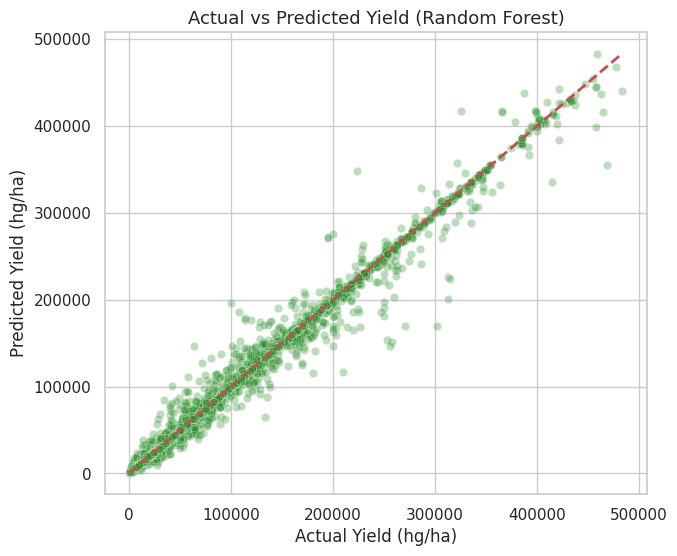

In [32]:
# Retain predictions from the top model (Random Forest is usually best here)
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test_processed)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.3, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual vs Predicted Yield (Random Forest)', fontsize=13)
plt.xlabel('Actual Yield (hg/ha)')
plt.ylabel('Predicted Yield (hg/ha)')
plt.show()

## 8, 9 & 10. Hyperparameter Tuning, Feature Importance, and Residual Diagnostics
- Tune the leading model (`RandomForestRegressor`) using `GridSearchCV`.
- Identify the most influential agricultural predictors.
- Run residual diagnostic plots to inspect prediction error distributions.

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Test R2 Score: 0.9876


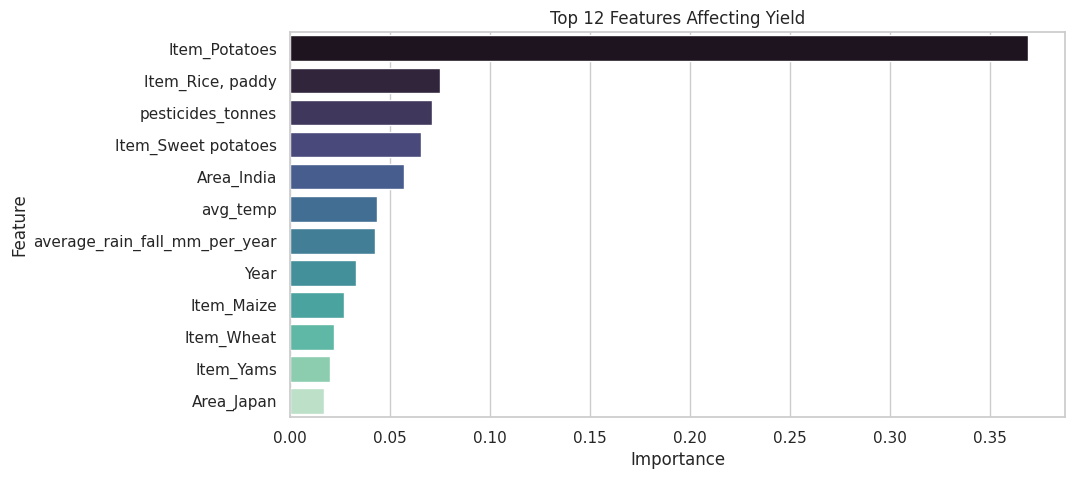

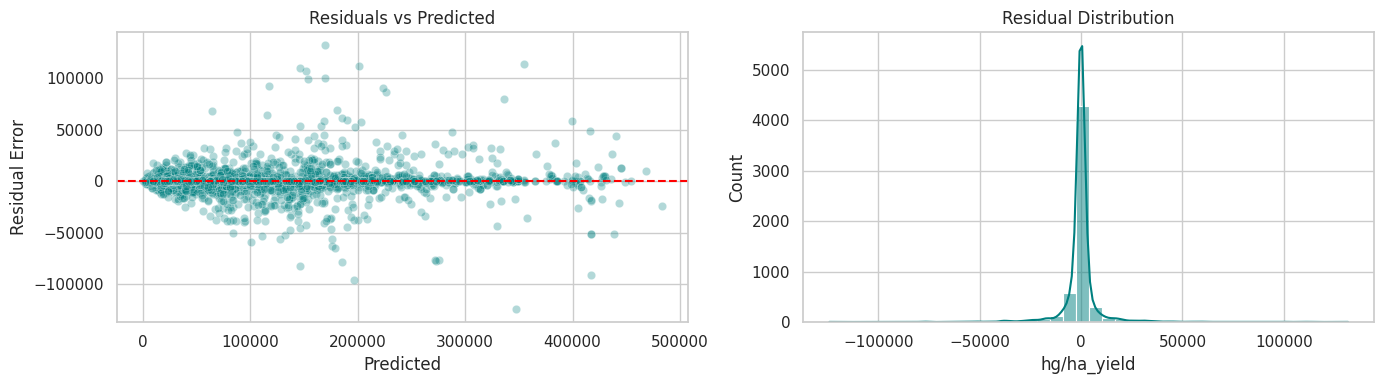

In [45]:
# 1. Hyperparameter Tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_processed, y_train)

best_rf = grid_search.best_estimator_
y_tuned_pred = best_rf.predict(X_test_processed)

print("Best Parameters:", grid_search.best_params_)
print(f"Tuned Test R2 Score: {r2_score(y_test, y_tuned_pred):.4f}")

# 2. Feature Importance
cat_encoder = preprocessor.named_transformers_['cat']
all_features = numerical_features + cat_encoder.get_feature_names_out(categorical_features).tolist()

feat_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df.head(12), x='Importance', y='Feature', palette='mako')
plt.title('Top 12 Features Affecting Yield')
plt.show()

# 3. Residual Diagnostics
residuals = y_test - y_tuned_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(x=y_tuned_pred, y=residuals, alpha=0.3, ax=axes[0], color='teal')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual Error')

sns.histplot(residuals, kde=True, ax=axes[1], color='teal', bins=40)
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

## 11 & 12. Save End-to-End Pipeline and Inference System
- Bundle preprocessing and the tuned model into a single deployable `Pipeline`.
- Export pipeline artifact to disk via `joblib`.
- Provide an inference function (`predict_crop_yield`) to predict yields on unseen raw inputs.

In [46]:
# 1. Build and fit pipeline on raw training inputs
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', best_rf)
])
final_pipeline.fit(X_train, y_train)

# 2. Save pipeline artifact
pipeline_path = 'crop_yield_pipeline.joblib'
joblib.dump(final_pipeline, pipeline_path)
print(f"Pipeline successfully saved to: {pipeline_path}")

# 3. Standalone Inference Function
def predict_crop_yield(area, item, year, rain_fall, pesticides, temp):
    input_data = pd.DataFrame([{
        'Area': area,
        'Item': item,
        'Year': year,
        'average_rain_fall_mm_per_year': rain_fall,
        'pesticides_tonnes': pesticides,
        'avg_temp': temp
    }])
    prediction = final_pipeline.predict(input_data)[0]
    return round(prediction, 2)

# Sample test run
sample_pred = predict_crop_yield(
    area='Albania',
    item='Maize',
    year=2013,
    rain_fall=1485.0,
    pesticides=121.0,
    temp=16.37
)
print(f"Sample Predicted Yield: {sample_pred:,} hg/ha")

Pipeline successfully saved to: crop_yield_pipeline.joblib
Sample Predicted Yield: 23,636.25 hg/ha
